In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("data/environmental_anomaly_results.csv")
print("Dataset loaded successfully!")
print("Rows:", len(df))


Dataset loaded successfully!
Rows: 12960


In [7]:
df = pd.read_csv("data/environmental_data.csv")
df.head()

,timestamp,location,temperature,humidity,co2,pm25,light_intensity
0,2026-02-13 19:30:00,Library,27.355886,55.056624,595.868432,16.413839,160.301006
1,2026-02-11 14:30:00,Library,26.447055,63.938421,1161.141613,24.165612,381.942461
2,2026-01-07 16:00:00,Classroom,25.817575,37.252268,937.170159,23.620237,316.548356
3,2026-02-06 04:00:00,Garden,26.155594,62.646433,325.800097,13.383179,503.400482
4,2026-01-06 16:30:00,Computer Lab,28.562936,58.966546,998.379360,17.397738,311.117835


In [8]:
df.shape


(12960, 7)

In [10]:
df.columns


Index(['timestamp', 'location', 'temperature', 'humidity', 'co2', 'pm25',
       'light_intensity'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        12960 non-null  str    
 1   location         12960 non-null  str    
 2   temperature      12960 non-null  float64
 3   humidity         12960 non-null  float64
 4   co2              12960 non-null  float64
 5   pm25             12960 non-null  float64
 6   light_intensity  12960 non-null  float64
dtypes: float64(5), str(2)
memory usage: 1.0 MB


In [12]:
df.describe()

,temperature,humidity,co2,pm25,light_intensity
count,12960.000000,12960.000000,12960.000000,12960.000000,12960.000000
mean,28.799795,58.860730,935.581598,29.570373,400.524432
std,3.407239,9.944989,325.092516,19.103242,205.264932
min,18.139368,20.000000,300.000000,1.000000,20.000000
25%,26.536135,52.518656,715.185725,17.774390,247.385399
50%,28.390953,58.596974,906.856504,24.841924,367.324112
75%,30.590049,64.996872,1111.710530,35.667391,526.151163
max,48.000000,95.000000,3123.147869,190.096062,1200.000000


In [13]:
df["location"].value_counts()


location
Library         2160
Classroom       2160
Garden          2160
Computer Lab    2160
Canteen         2160
Parking Area    2160
Name: count, dtype: int64

In [14]:
df.groupby("location")[
    ["temperature", "humidity", "co2", "pm25", "light_intensity"]
].mean().round(2)

,temperature,humidity,co2,pm25,light_intensity
location,,,,,
Canteen,30.51,63.03,1184.68,36.15,372.28
Classroom,28.03,57.02,929.12,25.12,312.96
Computer Lab,29.09,54.17,1063.97,27.24,452.10
Garden,25.58,68.84,600.72,17.07,497.80
Library,27.11,59.01,847.94,21.25,219.18
Parking Area,32.48,51.10,987.06,50.58,548.83


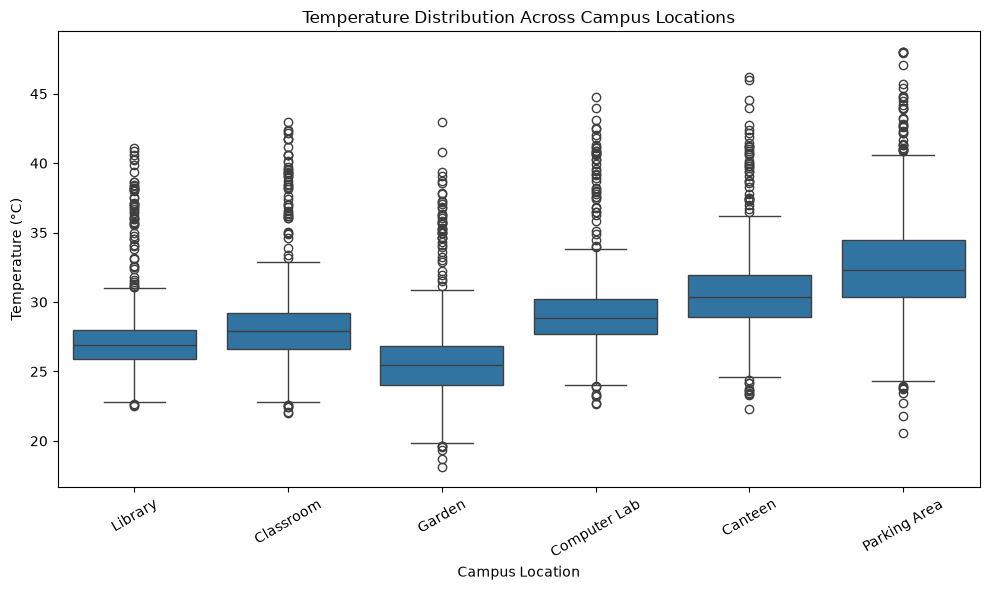

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="location",
    y="temperature"
)

plt.title("Temperature Distribution Across Campus Locations")
plt.xlabel("Campus Location")
plt.ylabel("Temperature (°C)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

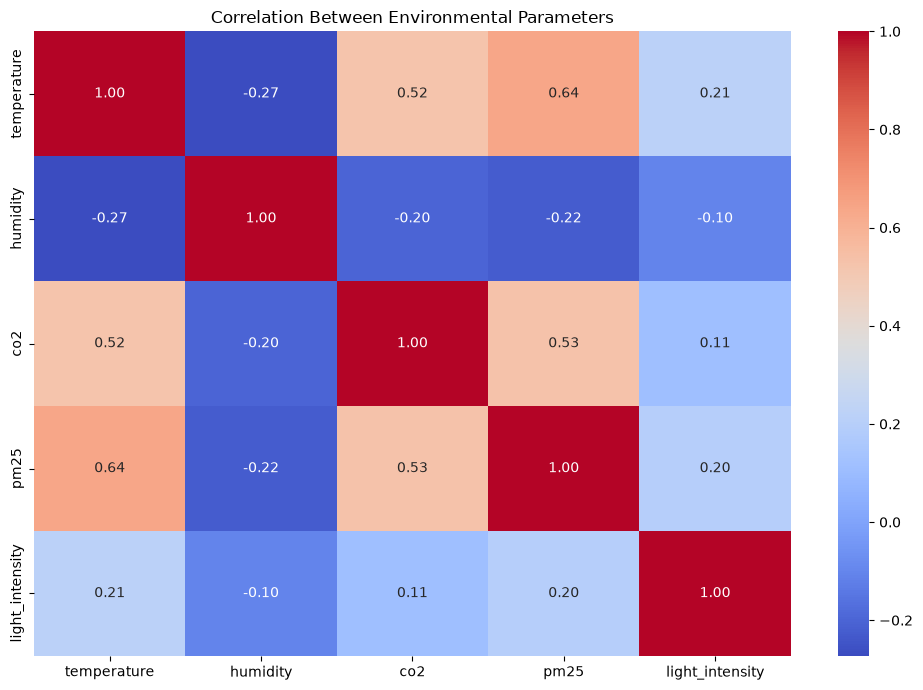

In [20]:
plt.figure(figsize=(10, 7))

correlation = df[
    ["temperature", "humidity", "co2", "pm25", "light_intensity"]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Environmental Parameters")
plt.tight_layout()
plt.show()

In [18]:
df.isnull().sum()



timestamp          0
location           0
temperature        0
humidity           0
co2                0
pm25               0
light_intensity    0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

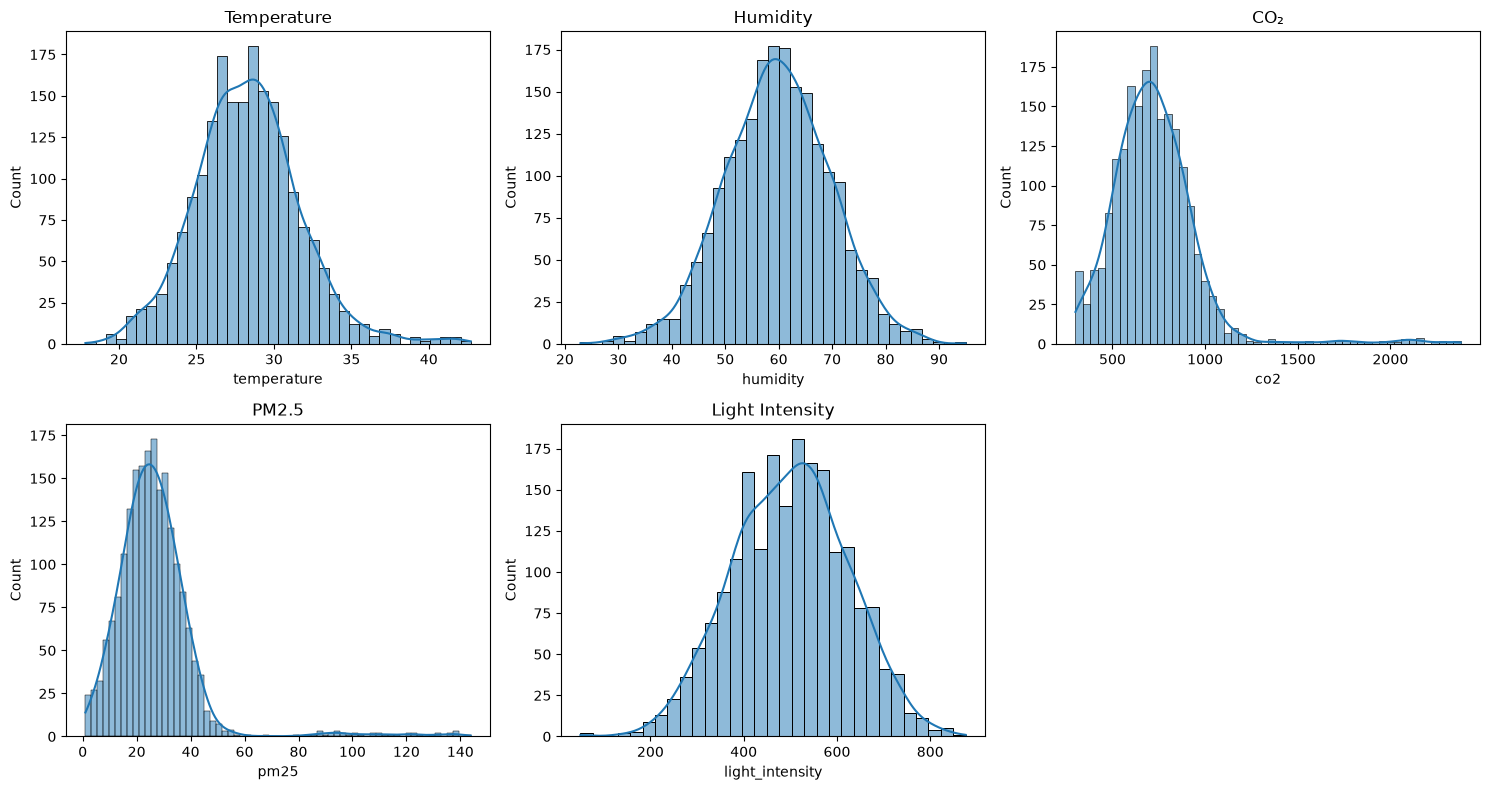

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(df["temperature"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Temperature")

sns.histplot(df["humidity"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Humidity")

sns.histplot(df["co2"], kde=True, ax=axes[0, 2])
axes[0, 2].set_title("CO₂")

sns.histplot(df["pm25"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("PM2.5")

sns.histplot(df["light_intensity"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Light Intensity")

axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

In [21]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df.dtypes

timestamp          datetime64[us]
location                      str
temperature               float64
humidity                  float64
co2                       float64
pm25                      float64
light_intensity           float64
dtype: object

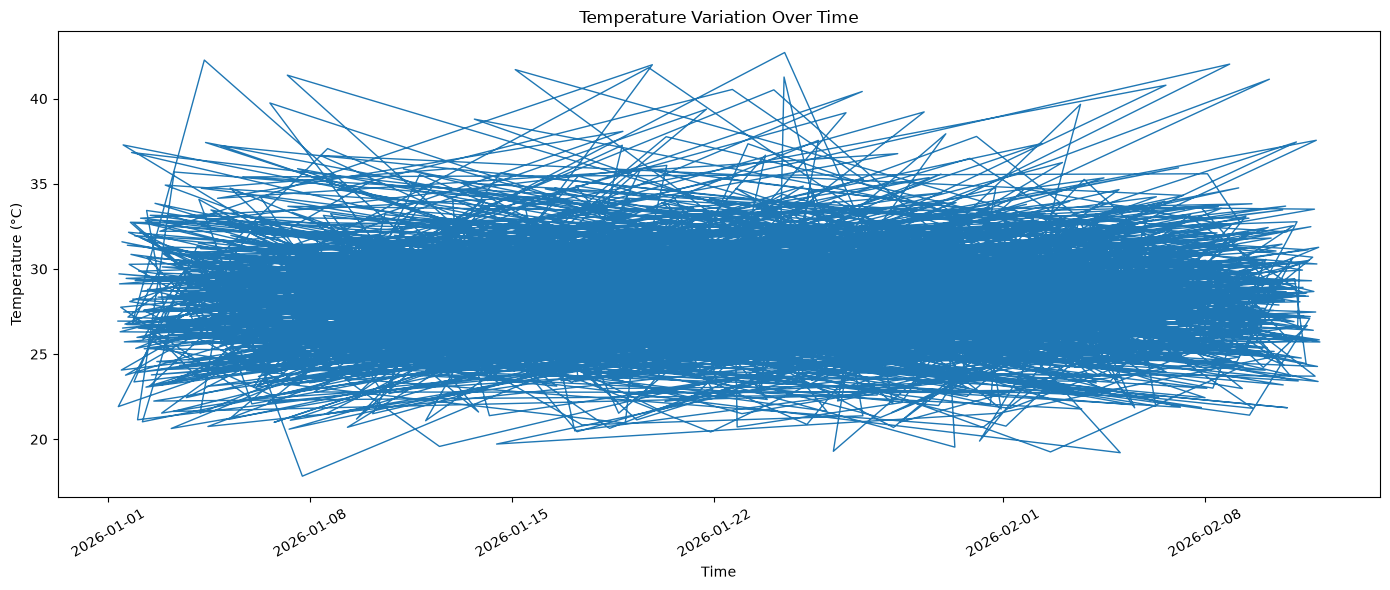

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["timestamp"],
    df["temperature"],
    linewidth=1
)

plt.title("Temperature Variation Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

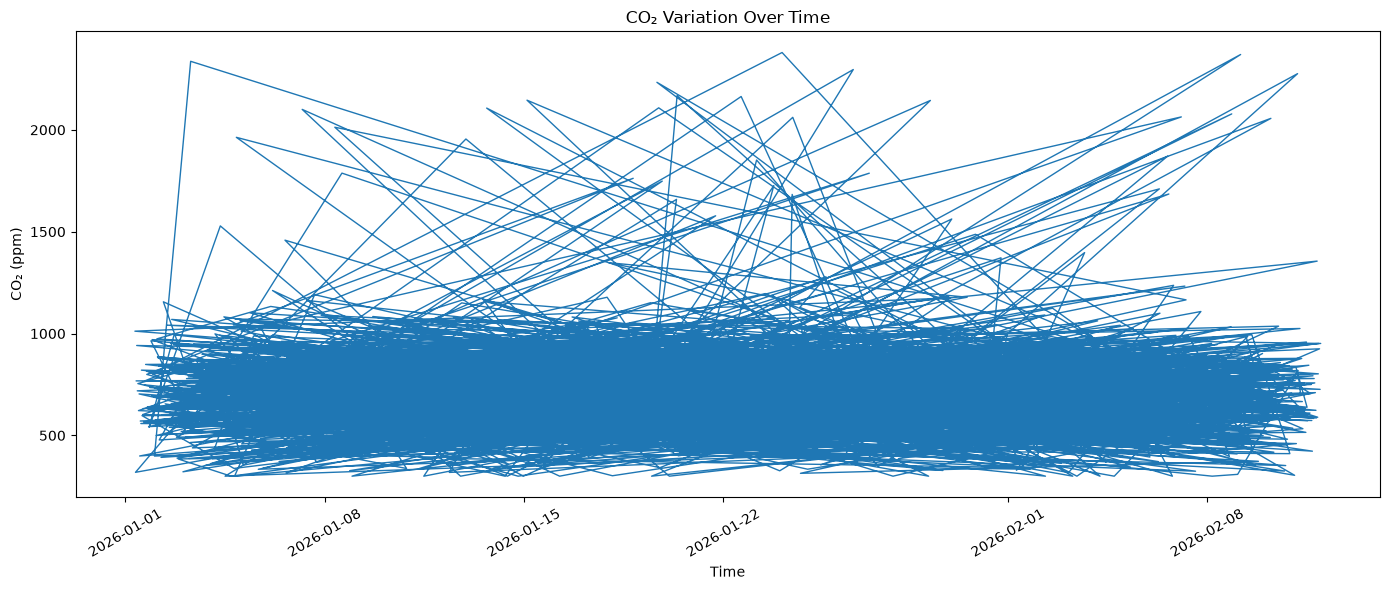

In [23]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["timestamp"],
    df["co2"],
    linewidth=1
)

plt.title("CO₂ Variation Over Time")
plt.xlabel("Time")
plt.ylabel("CO₂ (ppm)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

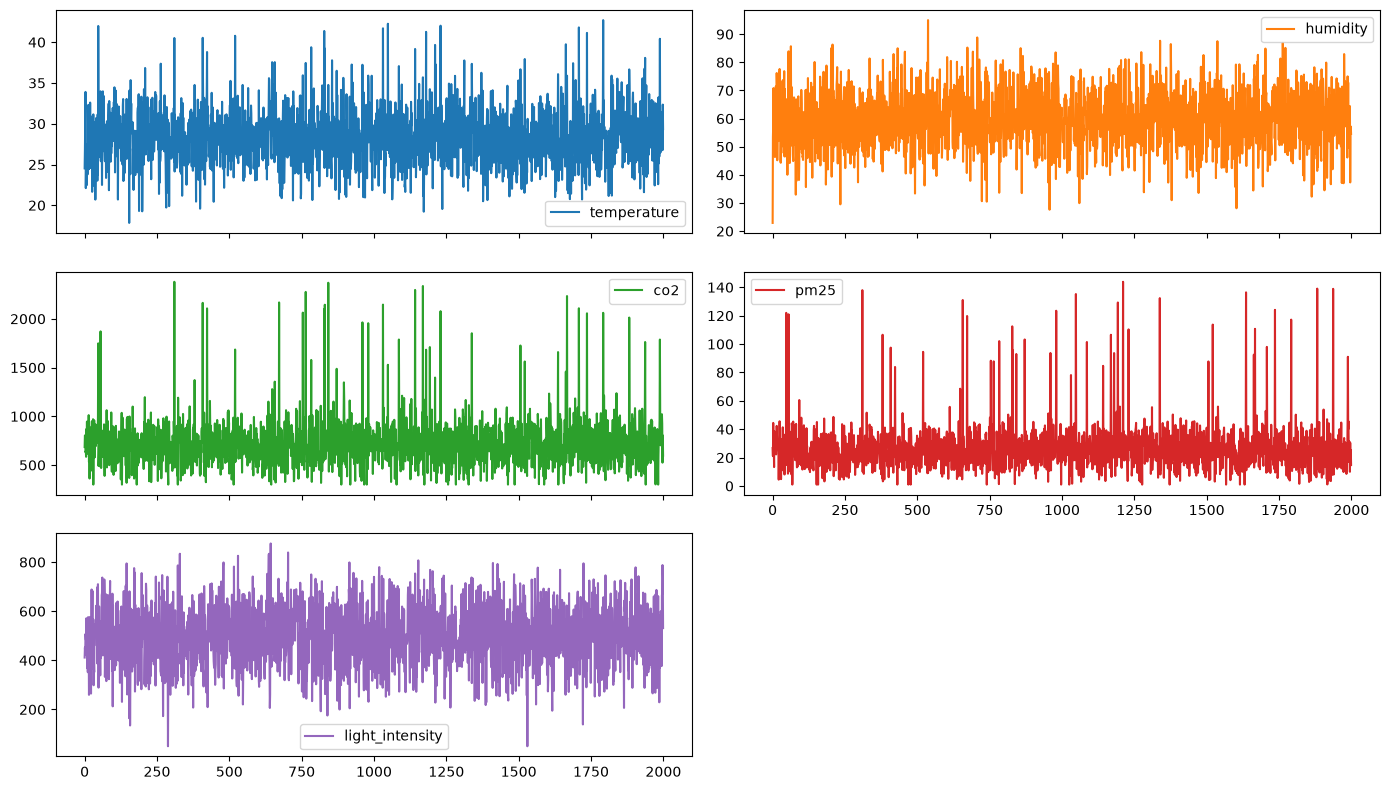

In [24]:
features = [
    "temperature",
    "humidity",
    "co2",
    "pm25",
    "light_intensity"
]

df[features].plot(
    figsize=(14, 8),
    subplots=True,
    layout=(3, 2),
    sharex=True
)

plt.tight_layout()
plt.show()

In [25]:
features = [
    "temperature",
    "humidity",
    "co2",
    "pm25",
    "light_intensity"
]

X = df[features]

X.head()

,temperature,humidity,co2,pm25,light_intensity
0,24.530392,22.912034,685.143630,26.729701,411.417971
1,26.847903,53.474909,804.094411,21.092944,452.146749
2,30.565460,58.019335,782.283570,44.439110,424.452009
3,33.903697,70.844296,631.511362,31.926720,507.420690
4,22.104698,54.769428,645.111058,26.578535,484.697522


In [26]:
X.shape


(2000, 5)

In [27]:
from sklearn.ensemble import IsolationForest

print("Isolation Forest imported successfully!")

Isolation Forest imported successfully!


In [28]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

print("Isolation Forest model created successfully!")

Isolation Forest model created successfully!


In [29]:
model.fit(X)

print("Model training completed successfully!")


Model training completed successfully!


In [30]:
df["anomaly"] = model.predict(X)

df["anomaly"].value_counts()

anomaly
 1    1960
-1      40
Name: count, dtype: int64

In [31]:
df["anomaly_label"] = df["anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

df["anomaly_label"].value_counts()


anomaly_label
Normal     1960
Anomaly      40
Name: count, dtype: int64

In [32]:
anomalies = df[df["anomaly_label"] == "Anomaly"]

anomalies.head(10)


,timestamp,location,temperature,humidity,co2,pm25,light_intensity,anomaly,anomaly_label
47,2026-01-19 20:30:00,Canteen,41.990302,58.996904,1748.283608,121.975705,506.499603,-1,Anomaly
55,2026-02-06 14:30:00,Parking Area,33.976622,83.915548,1871.054006,120.955465,544.682296,-1,Anomaly
310,2026-01-24 01:30:00,Classroom,40.516390,54.576917,2379.552229,137.973924,443.519092,-1,Anomaly
380,2026-01-31 18:00:00,Garden,34.755532,41.209038,1371.861889,106.554621,366.692793,-1,Anomaly
408,2026-01-22 15:00:00,Garden,40.539502,50.450114,2163.633572,97.474957,491.829021,-1,Anomaly
423,2026-01-13 16:30:00,Garden,38.796900,73.789017,2106.766648,83.858556,517.678700,-1,Anomaly
520,2026-02-06 15:30:00,Canteen,40.787860,60.459594,1684.975163,94.503650,461.093506,-1,Anomaly
648,2026-01-25 14:30:00,Parking Area,37.549697,74.958449,1278.684233,68.530007,474.094624,-1,Anomaly
657,2026-02-11 20:30:00,Canteen,37.554647,73.786714,1355.641355,131.029651,431.745339,-1,Anomaly
672,2026-01-20 09:00:00,Garden,30.661199,48.431507,2167.931081,119.763201,411.618842,-1,Anomaly


In [34]:
anomaly_by_location = (
    df[df["anomaly_label"] == "Anomaly"]
    .groupby("location")
    .size()
    .sort_values(ascending=False)
)

anomaly_by_location                                                     

location
Garden          10
Canteen          8
Parking Area     7
Classroom        6
Library          6
Computer Lab     3
dtype: int64

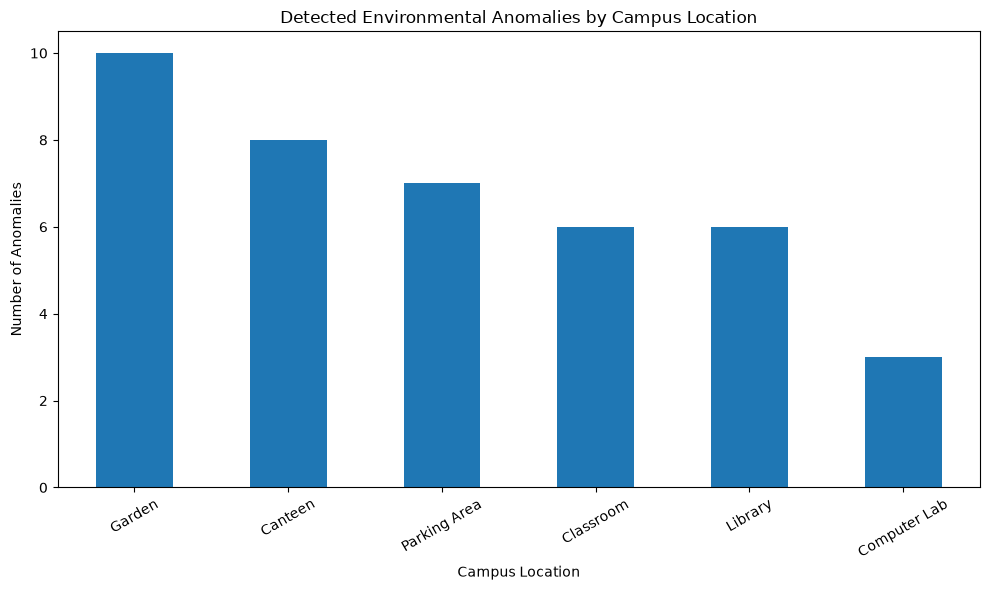

In [35]:
plt.figure(figsize=(10, 6))

anomaly_by_location.plot(kind="bar")

plt.title("Detected Environmental Anomalies by Campus Location")
plt.xlabel("Campus Location")
plt.ylabel("Number of Anomalies")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [23]:
total_observations = len(df)
total_anomalies = (df["anomaly_label"] == "Anomaly").sum()

anomaly_percentage = (total_anomalies / total_observations) * 100

print("Total observations:", total_observations)
print("Total anomalies:", total_anomalies)
print("Anomaly percentage:", round(anomaly_percentage, 2), "%")

Total observations: 12960
Total anomalies: 260
Anomaly percentage: 2.01 %


In [38]:
from sklearn.ensemble import IsolationForest

features = [
    "temperature",
    "humidity",
    "co2",
    "pm25",
    "light_intensity"
]

X = df[features]

model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

model.fit(X)

df["anomaly"] = model.predict(X)

df["anomaly_label"] = df["anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

print("Isolation Forest model trained successfully!")
print("Observations:", len(df))
print("Anomalies:", (df["anomaly_label"] == "Anomaly").sum())

Isolation Forest model trained successfully!
Observations: 12960
Anomalies: 260


In [39]:
df["anomaly_score"] = model.decision_function(X)

df[
    [
        "location",
        "temperature",
        "humidity",
        "co2",
        "pm25",
        "light_intensity",
        "anomaly_label",
        "anomaly_score"
    ]
].head(10)

,location,temperature,humidity,co2,pm25,light_intensity,anomaly_label,anomaly_score
0,Library,27.355886,55.056624,595.868432,16.413839,160.301006,Normal,0.203295
1,Library,26.447055,63.938421,1161.141613,24.165612,381.942461,Normal,0.218227
2,Classroom,25.817575,37.252268,937.170159,23.620237,316.548356,Normal,0.148241
3,Garden,26.155594,62.646433,325.800097,13.383179,503.400482,Normal,0.153571
4,Computer Lab,28.562936,58.966546,998.379360,17.397738,311.117835,Normal,0.236213
5,Library,24.859937,54.218829,992.818232,26.197596,325.280112,Normal,0.199109
6,Canteen,30.555661,66.660333,1013.413546,28.604728,162.808925,Normal,0.193307
7,Computer Lab,28.740219,49.510113,534.871218,35.016393,627.248183,Normal,0.162495
8,Library,26.893018,55.752798,709.937592,27.510687,326.601768,Normal,0.226748
9,Library,23.429086,60.655106,849.647188,27.425767,39.947983,Normal,0.127331


In [40]:
df.to_csv("data/environmental_anomaly_results.csv", index=False)

print("Final anomaly results saved successfully!")
print("Rows:", len(df))
print("Anomalies:", (df["anomaly_label"] == "Anomaly").sum())

Final anomaly results saved successfully!
Rows: 12960
Anomalies: 260


In [41]:
import joblib

joblib.dump(model, "models/isolation_forest_model.pkl")

print("Isolation Forest model saved successfully!")

Isolation Forest model saved successfully!


In [32]:
def get_severity(row):
    if row["anomaly_label"] == "Normal":
        return "Normal"
    
    score = row["anomaly_score"]
    
    if score < -0.15:
        return "High"
    elif score < -0.05:
        return "Medium"
    else:
        return "Low"


df["severity"] = df.apply(get_severity, axis=1)

df["severity"].value_counts()


severity
Normal    12700
Medium      151
Low         107
High          2
Name: count, dtype: int64

In [34]:
high_anomalies = df[df["severity"] == "High"]

high_anomalies[
    [
        "timestamp",
        "location",
        "temperature",
        "humidity",
        "co2",
        "pm25",
        "light_intensity",
        "anomaly_score",
        "severity"
    ]
].sort_values("anomaly_score").head(10)



,timestamp,location,temperature,humidity,co2,pm25,light_intensity,anomaly_score,severity
2140,2026-02-04 12:00:00,Parking Area,42.788563,83.956454,2698.163883,133.302875,1191.915721,-0.165876,High
7343,2026-02-06 15:30:00,Parking Area,43.973547,44.929202,2595.822046,161.239113,960.590477,-0.150995,High


In [40]:
df.to_csv("data/environmental_anomaly_results.csv", index=False)

print("AI anomaly results saved successfully!")

AI anomaly results saved successfully!


In [ ]:
results = pd.read_csv("data/environmental_anomaly_results.csv")

print("Rows:", len(results))
print("Columns:", len(results.columns))

results.head()


In [42]:
import joblib

joblib.dump(model, "models/isolation_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


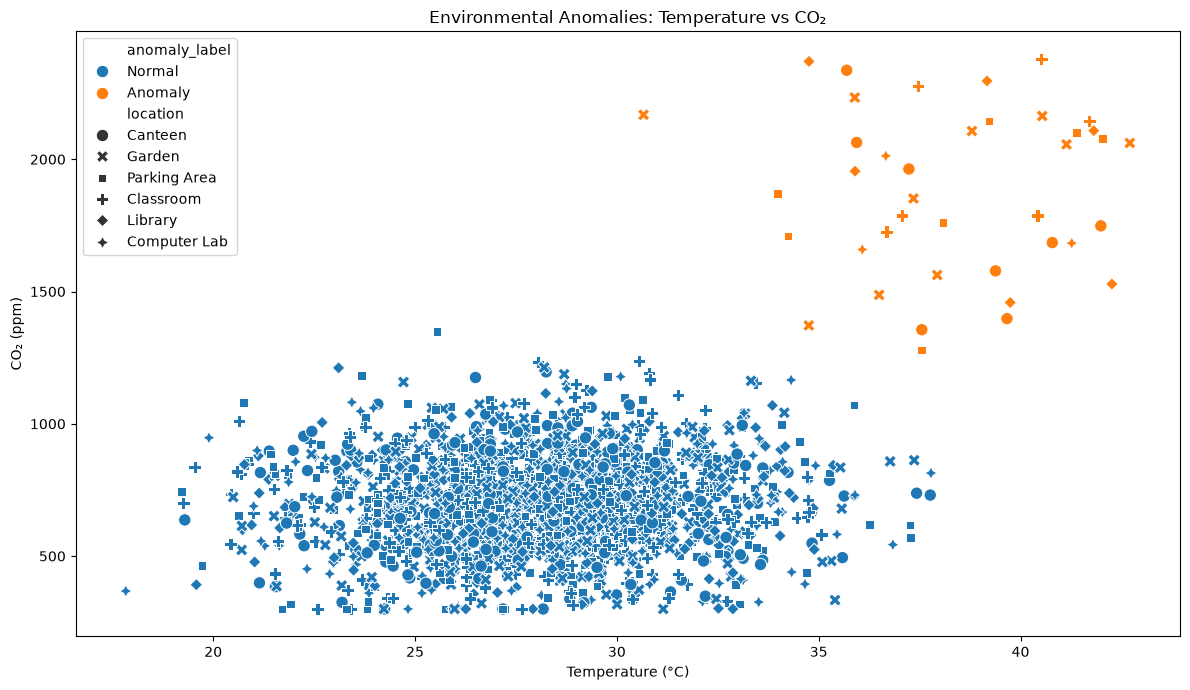

In [43]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="temperature",
    y="co2",
    hue="anomaly_label",
    style="location",
    s=80
)

plt.title("Environmental Anomalies: Temperature vs CO₂")
plt.xlabel("Temperature (°C)")
plt.ylabel("CO₂ (ppm)")

plt.tight_layout()
plt.show()

In [4]:
comparison = df.groupby("anomaly_label")[
    [
        "temperature",
        "humidity",
        "co2",
        "pm25",
        "light_intensity"
    ]
].mean().round(2)

comparison

,temperature,humidity,co2,pm25,light_intensity
anomaly_label,,,,,
Anomaly,38.31,58.09,1882.68,108.68,489.88
Normal,28.11,59.83,701.76,24.89,499.68


In [5]:
df.columns


Index(['timestamp', 'location', 'temperature', 'humidity', 'co2', 'pm25',
       'light_intensity', 'anomaly', 'anomaly_label', 'anomaly_score',
       'severity'],
      dtype='str')

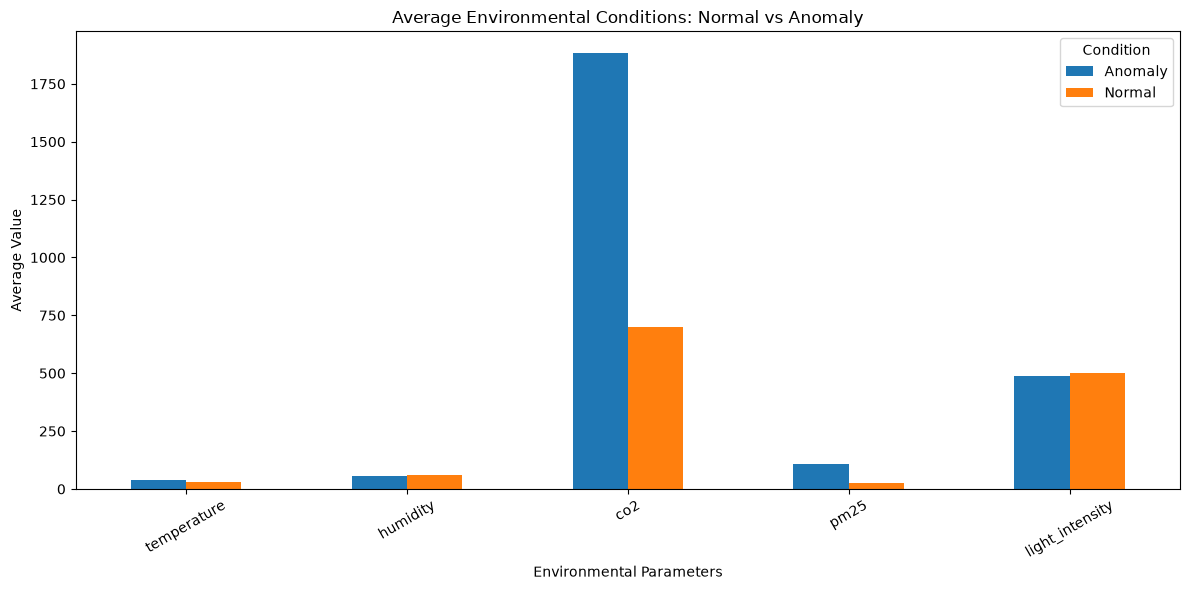

In [7]:
comparison.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Environmental Conditions: Normal vs Anomaly")
plt.xlabel("Environmental Parameters")
plt.ylabel("Average Value")

plt.xticks(rotation=30)
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

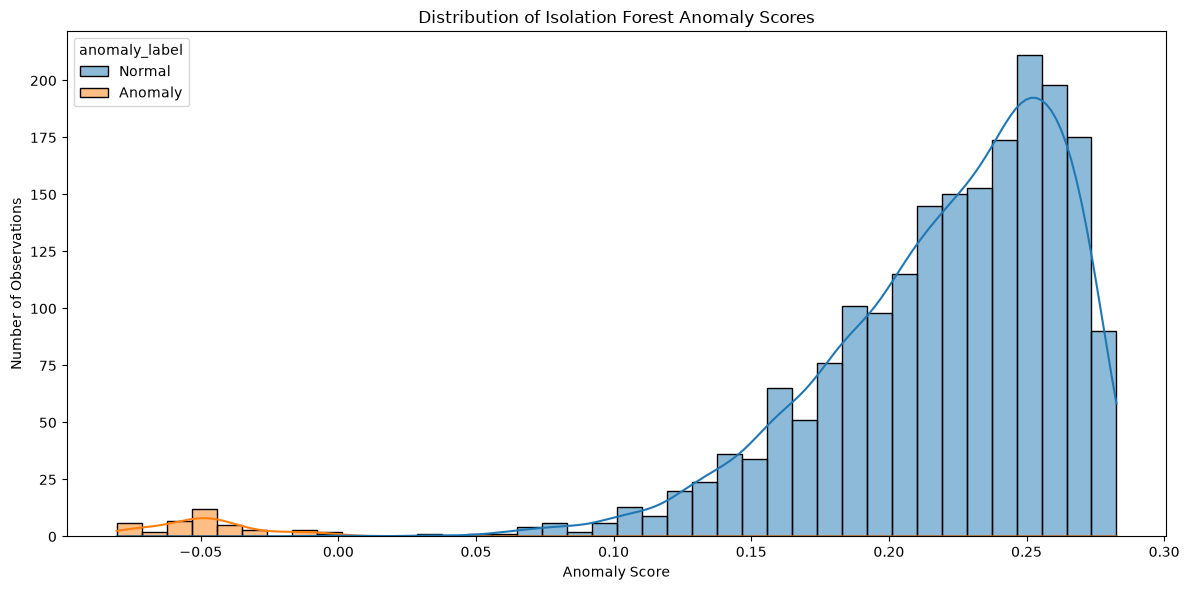

In [8]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="anomaly_score",
    hue="anomaly_label",
    bins=40,
    kde=True
)

plt.title("Distribution of Isolation Forest Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

In [9]:
df.groupby("anomaly_label")["anomaly_score"].mean().round(4)

anomaly_label
Anomaly   -0.0479
Normal     0.2210
Name: anomaly_score, dtype: float64

In [10]:
location_summary = df.groupby("location").agg(
    total_observations=("location", "size"),
    anomalies=("anomaly_label", lambda x: (x == "Anomaly").sum())
)

location_summary["anomaly_percentage"] = (
    location_summary["anomalies"]
    / location_summary["total_observations"]
    * 100
).round(2)

location_summary.sort_values(
    "anomaly_percentage",
    ascending=False
)

,total_observations,anomalies,anomaly_percentage
location,,,
Garden,330,10,3.03
Canteen,326,8,2.45
Parking Area,337,7,2.08
Library,326,6,1.84
Classroom,352,6,1.70
Computer Lab,329,3,0.91


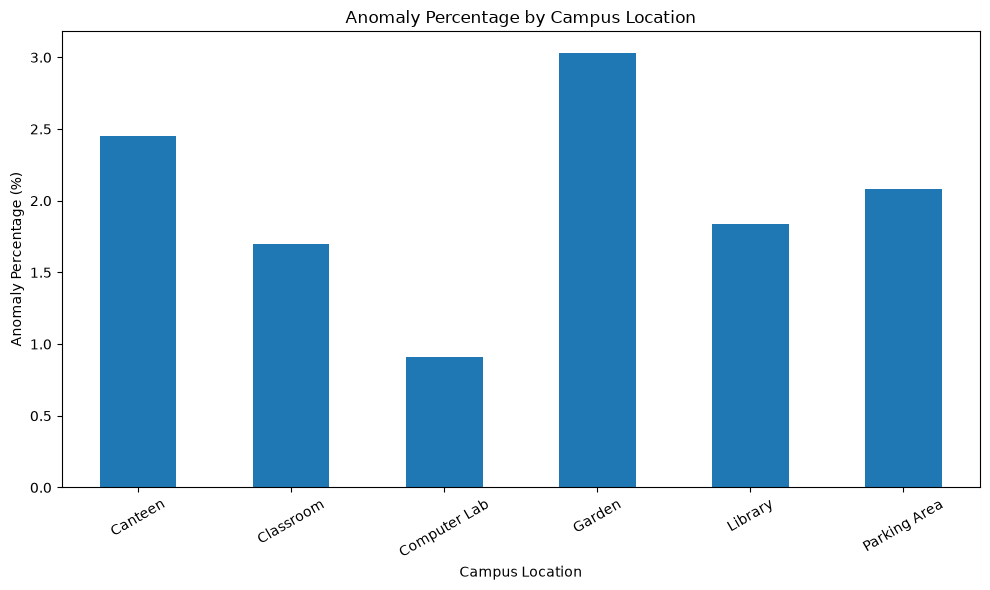

In [11]:
plt.figure(figsize=(10, 6))

location_summary["anomaly_percentage"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Anomaly Percentage by Campus Location")
plt.xlabel("Campus Location")
plt.ylabel("Anomaly Percentage (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [14]:
features = [
    "temperature",
    "humidity",
    "co2",
    "pm25",
    "light_intensity"
]

In [15]:
print("===== MicroClimate AI Model Summary =====")
print("Total observations:", len(df))
print("Total anomalies:", (df["anomaly_label"] == "Anomaly").sum())
print("Anomaly percentage:",
      round((df["anomaly_label"] == "Anomaly").mean() * 100, 2), "%")
print("Campus locations:", df["location"].nunique())
print("Features used:", features)

===== MicroClimate AI Model Summary =====
Total observations: 2000
Total anomalies: 40
Anomaly percentage: 2.0 %
Campus locations: 6
Features used: ['temperature', 'humidity', 'co2', 'pm25', 'light_intensity']
